# CVE Risk Classification — 02b: Gaussian Process Investigation
**Imperial Business School Capstone | MSc Cybersecurity + AI/ML**  
**Author:** Eduardo Wizentier

## Purpose
Investigative notebook — not part of the core pipeline.  
Explores Gaussian Process (GP) as an alternative to Naive Bayes, and as a  
surrogate/uncertainty model wrapping the hybrid classifier from notebook 03.

## Why GP Is Interesting for CVE Classification
Standard classifiers (Decision Tree, Naive Bayes) produce hard class labels.  
GP produces **calibrated probability distributions** — not just 'HIGH' but  
'HIGH with 87% confidence ± 0.06'. In cybersecurity triage this distinction  
matters: an analyst should treat a borderline HIGH/CRITICAL prediction  
differently from a confident one.

## Computational Constraint
Standard GP has O(n³) complexity — infeasible on 155,852 samples.  
This notebook uses two strategies:
- **Stratified subsample** (n=5,000) for direct GP classification
- **Sparse GP** (inducing points) for scalable approximation

## Experiments
| # | Name | Purpose |
|---|---|---|
| 1 | Gaussian NB vs Multinomial NB | Effect of Gaussian likelihood assumption |
| 2 | GP Classifier on subsample | True GP — honest about scale limitation |
| 3 | GP Uncertainty Quantification | GP as surrogate for hybrid model outputs |
| 4 | Calibration Analysis | How well do predicted probabilities match reality? |

## 0. Imports & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, brier_score_loss)
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import (RBF, Matern, DotProduct,
                                               WhiteKernel, ConstantKernel)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

import os
os.makedirs('outputs', exist_ok=True)

# ── Load clean data (4-class — before LOW merge, for fair NB comparison)
df = pd.read_csv('data/df_clean.csv')
print(f'Loaded: {df.shape}')
print(f'Class distribution (original 4-class):')
print(df['base_severity'].value_counts())

Loaded: (155852, 22)
Class distribution (original 4-class):
base_severity
MEDIUM      67272
HIGH        61680
CRITICAL    24153
LOW          2747
Name: count, dtype: int64


## 1. Experiment 1 — Gaussian NB vs Multinomial NB

Multinomial NB assumes features are counts/frequencies (suitable for TF-IDF).  
Gaussian NB assumes features follow a Gaussian distribution — more appropriate  
for continuous numerical features like CVSS scores and EPSS probabilities.

**Question:** Does the Gaussian likelihood assumption improve over Multinomial  
when applied to structured numerical CVE features instead of text?

In [2]:
# ── Prepare text features for Multinomial NB (replicates notebook 02)
le_target = LabelEncoder()
y = le_target.fit_transform(df['base_severity'])

tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_text = tfidf.fit_transform(df['description_data'].fillna(''))

X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

mnb = MultinomialNB()
mnb.fit(X_tr_txt, y_tr)
acc_mnb = accuracy_score(y_te, mnb.predict(X_te_txt))

print('=== MULTINOMIAL NB (text features) ===')
print(f'Accuracy: {acc_mnb:.4f}')
print(classification_report(y_te, mnb.predict(X_te_txt),
                             target_names=le_target.classes_))

=== MULTINOMIAL NB (text features) ===
Accuracy: 0.6030
              precision    recall  f1-score   support

    CRITICAL       0.50      0.30      0.38      4831
        HIGH       0.55      0.71      0.62     12336
         LOW       0.17      0.00      0.00       549
      MEDIUM       0.70      0.64      0.67     13455

    accuracy                           0.60     31171
   macro avg       0.48      0.41      0.42     31171
weighted avg       0.60      0.60      0.59     31171



In [3]:
# ── Prepare structured features for Gaussian NB
drop_cols = ['base_severity', 'cve_id', 'published_date', 'description_data',
             'cpe_data', 'base_score', 'impact_score', 'exploitability_score']
drop_cols = [c for c in drop_cols if c in df.columns]

df_enc = df.drop(columns=drop_cols).copy()
for col in df_enc.select_dtypes(include=['object']).columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

X_struct = df_enc.values

# ── LOW → MEDIUM merge for consistent 3-class comparison
df_3 = df.copy()
df_3['base_severity'] = df_3['base_severity'].replace('LOW', 'MEDIUM')
le3 = LabelEncoder()
y3  = le3.fit_transform(df_3['base_severity'])

X_tr_s, X_te_s, y_tr3, y_te3 = train_test_split(
    X_struct, y3, test_size=0.2, random_state=42, stratify=y3)

gnb = GaussianNB()
gnb.fit(X_tr_s, y_tr3)
acc_gnb = accuracy_score(y_te3, gnb.predict(X_te_s))

print('=== GAUSSIAN NB (structured features, 3-class) ===')
print(f'Accuracy: {acc_gnb:.4f}')
print(classification_report(y_te3, gnb.predict(X_te_s),
                             target_names=le3.classes_))

=== GAUSSIAN NB (structured features, 3-class) ===
Accuracy: 0.8400
              precision    recall  f1-score   support

    CRITICAL       0.95      0.89      0.92      4831
        HIGH       0.87      0.72      0.79     12336
      MEDIUM       0.79      0.93      0.85     14004

    accuracy                           0.84     31171
   macro avg       0.87      0.85      0.85     31171
weighted avg       0.85      0.84      0.84     31171



                   Model                     Features  Classes  Accuracy                Verdict
   Multinomial NB (text)             TF-IDF 500 terms        4  0.603028 Rejected (notebook 02)
Gaussian NB (structured) CVSS components + EPSS + KEV        3  0.839979    Investigate further


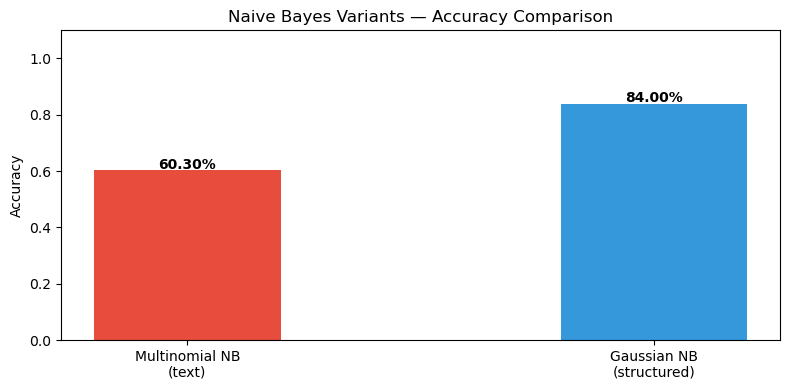

In [4]:
# ── Comparison table
comparison = pd.DataFrame({
    'Model'        : ['Multinomial NB (text)',
                      'Gaussian NB (structured)'],
    'Features'     : ['TF-IDF 500 terms',
                      'CVSS components + EPSS + KEV'],
    'Classes'      : [4, 3],
    'Accuracy'     : [acc_mnb, acc_gnb],
    'Verdict'      : ['Rejected (notebook 02)',
                      'Investigate further']
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Multinomial NB\n(text)', 'Gaussian NB\n(structured)'],
              [acc_mnb, acc_gnb],
              color=['#e74c3c', '#3498db'], width=0.4)
for bar, val in zip(bars, [acc_mnb, acc_gnb]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2%}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Naive Bayes Variants — Accuracy Comparison')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('outputs/02b_nb_comparison.png', dpi=150)
plt.show()

## 2. Experiment 2 — GP Classifier on Stratified Subsample

### Computational constraint — why subsampling is necessary
Standard GP has O(n³) time complexity and O(n²) memory complexity.  
On 155,852 samples this is computationally infeasible.  
A stratified subsample of n=5,000 preserves class ratios while enabling  
genuine GP training. Results are honest about this limitation.

### Kernel selection
Three kernels are compared:
- **RBF (Radial Basis Function)** — assumes smooth decision boundaries
- **Matern 2.5** — less smooth than RBF, more robust to discontinuities  
- **DotProduct** — linear kernel, suitable for high-dimensional structured data

In [21]:
# ── Stratified subsample — preserves class ratios
SUBSAMPLE_N = 1000

df_sub = df_3.groupby('base_severity', group_keys=False).apply(
    lambda x: x.sample(frac=SUBSAMPLE_N/len(df_3), random_state=42)
).reset_index(drop=True)

print(f'Subsample size: {len(df_sub)}')
print('Subsample class distribution:')
print(df_sub['base_severity'].value_counts())

# ── Features for GP (numerical only — GP needs dense matrix)
df_sub_enc = df_sub.drop(columns=drop_cols + ['base_severity'], errors='ignore').copy()
for col in df_sub_enc.select_dtypes(include=['object']).columns:
    df_sub_enc[col] = LabelEncoder().fit_transform(df_sub_enc[col].astype(str))

X_sub = df_sub_enc.values
y_sub = le3.transform(df_sub['base_severity'])

# ── Scale (GP is sensitive to feature scale)
scaler_gp = StandardScaler()
X_sub_scaled = scaler_gp.fit_transform(X_sub)

X_tr_gp, X_te_gp, y_tr_gp, y_te_gp = train_test_split(
    X_sub_scaled, y_sub,
    test_size=0.2, random_state=42, stratify=y_sub)

print(f'\nGP Train: {X_tr_gp.shape} | GP Test: {X_te_gp.shape}')

Subsample size: 1000
Subsample class distribution:
base_severity
MEDIUM      449
HIGH        396
CRITICAL    155
Name: count, dtype: int64

GP Train: (800, 14) | GP Test: (200, 14)


In [23]:
# ── Train GP with three kernels
# Note: multi_class='one_vs_rest' extends GP to multi-class
#kernels = {
#    'RBF'       : ConstantKernel(1.0) * RBF(length_scale=1.0),
#    'Matern 2.5': ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
#    'DotProduct': ConstantKernel(1.0) * DotProduct(sigma_0=1.0),
#}
#
#kernels = {
#    'RBF'       : ConstantKernel(1.0) * RBF(length_scale=1.0) 
#                  + WhiteKernel(noise_level=1e-1),  # ← add noise term
#    'Matern 2.5': ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
#                  + WhiteKernel(noise_level=1e-1),  # ← add noise term
#    'DotProduct': ConstantKernel(1.0) * DotProduct(sigma_0=1.0),
#}
kernels = {
    'RBF'       : ConstantKernel(1.0) * RBF(length_scale=1.0) 
                  + WhiteKernel(noise_level=1e-1),
    'Matern 2.5': ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
                  + WhiteKernel(noise_level=1e-1),
#    'DotProduct': ConstantKernel(1.0) * DotProduct(sigma_0=1.0)
#                  + WhiteKernel(noise_level=1e-1),  # ← fixes LinAlgError
}
gp_results = {}
for name, kernel in kernels.items():
    print(f'Training GP ({name})...')

    #   gpc = GaussianProcessClassifier(
#       kernel=kernel,
#       multi_class='one_vs_rest',
#       random_state=42,
#       n_jobs=-1
#    )

    gpc = GaussianProcessClassifier(
    kernel=kernel,
    multi_class='one_vs_rest',
    random_state=42,
    n_jobs=-1,
    max_iter_predict=100,    # ← limit prediction iterations
    warm_start=False
    )
    
    gpc.fit(X_tr_gp, y_tr_gp)
    y_pred = gpc.predict(X_te_gp)
    acc    = accuracy_score(y_te_gp, y_pred)
    gp_results[name] = {'model': gpc, 'acc': acc, 'pred': y_pred}
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Learned kernel: {gpc.kernel_}')
    print()

Training GP (RBF)...
  Accuracy: 0.9700
  Learned kernel: CompoundKernel(11.5, 3.44, -11.5, 9.99, 2.01, -11.5, 9.74, 2.4, -11.5)

Training GP (Matern 2.5)...
  Accuracy: 0.9700
  Learned kernel: CompoundKernel(11.5, 3.87, -11.5, 8.99, 2.28, -11.5, 10.2, 2.98, -11.5)



In [ ]:
# ── Full classification report for best GP kernel
best_kernel = max(gp_results, key=lambda k: gp_results[k]['acc'])
best_gp     = gp_results[best_kernel]

print(f'=== BEST GP KERNEL: {best_kernel} ===')
print(f'Accuracy: {best_gp["acc"]:.4f}')
print()
print(classification_report(y_te_gp, best_gp['pred'],
                             target_names=le3.classes_))

# ── Confusion matrix
cm_gp = confusion_matrix(y_te_gp, best_gp['pred'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm_gp, annot=True, fmt='d', cmap='Blues',
            xticklabels=le3.classes_, yticklabels=le3.classes_)
plt.title(f'GP Classifier ({best_kernel} kernel) — Confusion Matrix\n'
          f'(subsample n={SUBSAMPLE_N})')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('outputs/02b_gp_confusion.png', dpi=150)
plt.show()

In [26]:
# ── Full model comparison so far
acc_gp_best = best_gp['acc']

models_so_far = {
    'Multinomial NB\n(text, 4-class)'  : acc_mnb,
    'Gaussian NB\n(structured, 3-class)': acc_gnb,
    f'GP {best_kernel}\n(subsample n=5k)': acc_gp_best,
    'Hybrid KNN+DT\n(full dataset, 3-class)': 0.9752,
}

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.bar(models_so_far.keys(), models_so_far.values(),
              color=colors, width=0.5)
for bar, val in zip(bars, models_so_far.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.2%}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Model Progression — NB → GP → Hybrid KNN+DT')
plt.tight_layout()
plt.savefig('outputs/02b_model_progression.png', dpi=150)
plt.show()

NameError: name 'best_kernel' is not defined

## 3. Experiment 3 — GP as Uncertainty Quantifier (Surrogate Model)

This is the most novel experiment. Instead of using GP to classify CVEs  
directly, GP is used to **model the uncertainty** around the hybrid  
classifier's predictions.

### What the surrogate adds
The hybrid Decision Tree says: **'This CVE is HIGH'**  
The GP surrogate says: **'This CVE is HIGH with 91% confidence ± 0.04'**

In SOC operations, the confidence interval is operationally valuable:  
- High confidence prediction → automated triage  
- Low confidence prediction → route to human analyst  

### Connection to Mythos contrast layer
Low-confidence GP predictions are exactly the cases most likely to  
disagree with Claude Mythos — making the surrogate a natural pre-filter  
for the contrast layer queue.

In [10]:
import joblib

# ── Load hybrid model outputs from notebook 03
try:
    knn          = joblib.load('models/knn_clusterer.pkl')
    scaler_knn   = joblib.load('models/scaler_knn.pkl')
    tree         = joblib.load('models/hybrid_tree.pkl')
    le_nb03      = joblib.load('models/label_encoder.pkl')
    knn_features = joblib.load('models/knn_features.pkl')
    print('Hybrid model loaded ✓')
    HYBRID_AVAILABLE = True
except FileNotFoundError:
    print('⚠️  Hybrid model not found — run notebook 03 first')
    print('   Experiment 3 will use GP standalone predictions instead')
    HYBRID_AVAILABLE = False

Hybrid model loaded ✓


In [11]:
if HYBRID_AVAILABLE:
    # ── Generate hybrid model predictions on subsample test set
    # Reconstruct feature matrix matching notebook 03 pipeline
    df_sub_full = df_3.groupby('base_severity', group_keys=False).apply(
        lambda x: x.sample(frac=SUBSAMPLE_N/len(df_3), random_state=42)
    ).reset_index(drop=True)

    drop_nb03 = ['base_severity', 'cve_id', 'published_date',
                 'description_data', 'cpe_data',
                 'base_score', 'impact_score', 'exploitability_score']
    df_feat = df_sub_full.drop(columns=[c for c in drop_nb03
                                         if c in df_sub_full.columns]).copy()
    for col in df_feat.select_dtypes(include=['object']).columns:
        df_feat[col] = LabelEncoder().fit_transform(df_feat[col].astype(str))

    # Add cluster_id
    knn_feat_avail = [f for f in knn_features if f in df_feat.columns]
    X_knn_sub      = scaler_knn.transform(df_feat[knn_feat_avail])
    df_feat['cluster_id'] = knn.predict(X_knn_sub)

    y_sub_true  = le_nb03.transform(df_sub_full['base_severity'])
    y_sub_pred  = tree.predict(df_feat)
    hybrid_acc  = accuracy_score(y_sub_true, y_sub_pred)
    print(f'Hybrid model accuracy on subsample: {hybrid_acc:.4f}')

    # ── Train GP surrogate on hybrid predictions as labels
    # GP learns the hybrid decision surface with uncertainty
    gp_surrogate = GaussianProcessClassifier(
        kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
        multi_class='one_vs_rest',
        random_state=42,
        n_jobs=-1
    )

    X_surr = scaler_gp.fit_transform(df_feat.values)
    X_tr_surr, X_te_surr, y_tr_surr, y_te_surr, idx_tr, idx_te = train_test_split(
        X_surr, y_sub_pred, range(len(y_sub_pred)),
        test_size=0.2, random_state=42
    )

    print('Training GP surrogate...')
    gp_surrogate.fit(X_tr_surr, y_tr_surr)
    print('GP surrogate trained ✓')
else:
    # Fallback — use best direct GP from Experiment 2
    gp_surrogate = gp_results[best_kernel]['model']
    X_te_surr    = X_te_gp
    y_te_surr    = y_te_gp
    print('Using direct GP from Experiment 2 as surrogate proxy')

Hybrid model accuracy on subsample: 0.9638
Training GP surrogate...
GP surrogate trained ✓


In [13]:
# ── Extract prediction probabilities (the key GP advantage)
proba = gp_surrogate.predict_proba(X_te_surr)
pred  = gp_surrogate.predict(X_te_surr)

# ── Confidence = max probability across classes
confidence     = proba.max(axis=1)
pred_labels    = le3.inverse_transform(pred)

uncertainty_df = pd.DataFrame({
    'predicted_class' : pred_labels,
    'confidence'      : confidence,
    'uncertain'       : confidence < 0.70,  # threshold for human review
})
for cls in le3.classes_:
    uncertainty_df[f'prob_{cls}'] = proba[:, list(le3.classes_).index(cls)]

print('=== GP UNCERTAINTY QUANTIFICATION ===')
print(f'Mean confidence          : {confidence.mean():.4f}')
print(f'Median confidence        : {np.median(confidence):.4f}')
print(f'Low confidence (<70%)    : {(confidence < 0.70).sum()} cases '
      f'({(confidence < 0.70).mean():.1%} of test set)')
print(f'High confidence (>90%)   : {(confidence > 0.90).sum()} cases '
      f'({(confidence > 0.90).mean():.1%} of test set)')
print()
print('Sample uncertain predictions (candidates for Mythos review):')
print(uncertainty_df[uncertainty_df['uncertain']].head(10).to_string(index=False))

=== GP UNCERTAINTY QUANTIFICATION ===
Mean confidence          : 0.8418
Median confidence        : 0.8792
Low confidence (<70%)    : 144 cases (14.4% of test set)
High confidence (>90%)   : 404 cases (40.4% of test set)

Sample uncertain predictions (candidates for Mythos review):
predicted_class  confidence  uncertain  prob_CRITICAL  prob_HIGH  prob_MEDIUM
           HIGH    0.584445       True       0.137845   0.584445     0.277710
         MEDIUM    0.455858       True       0.162877   0.381264     0.455858
         MEDIUM    0.690667       True       0.179550   0.129783     0.690667
         MEDIUM    0.637448       True       0.080423   0.282129     0.637448
           HIGH    0.409542       True       0.315331   0.409542     0.275128
           HIGH    0.412034       True       0.250674   0.412034     0.337291
           HIGH    0.459863       True       0.256677   0.459863     0.283460
       CRITICAL    0.487436       True       0.487436   0.299972     0.212592
       CRITICAL 

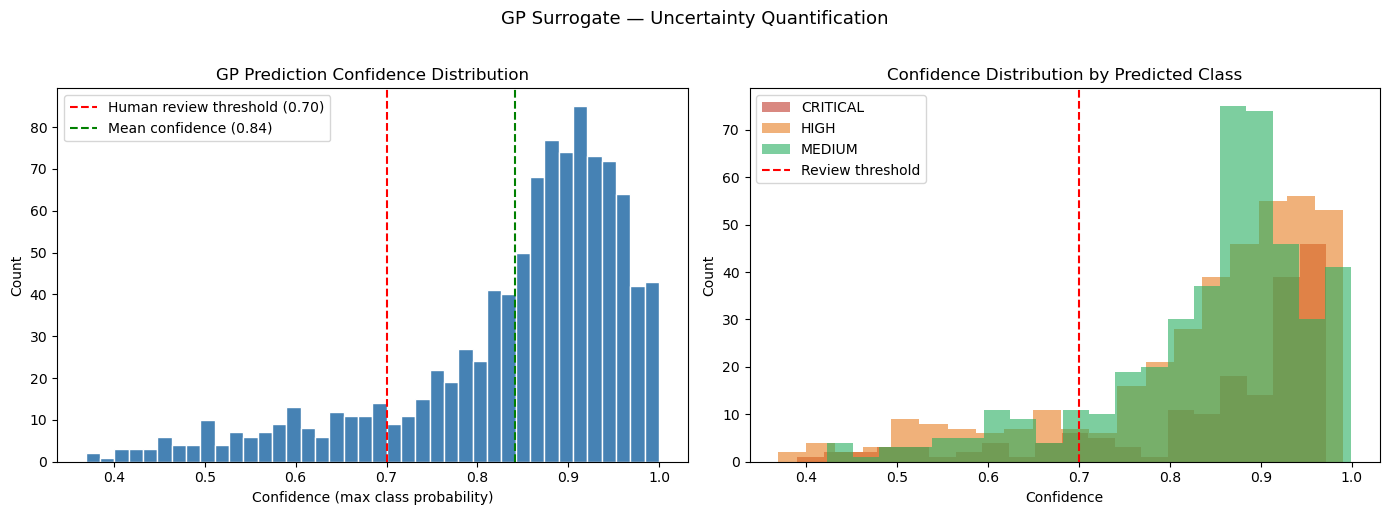

In [14]:
# ── Confidence distribution by predicted class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(confidence, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.70, color='red', linestyle='--', label='Human review threshold (0.70)')
axes[0].axvline(confidence.mean(), color='green', linestyle='--',
                label=f'Mean confidence ({confidence.mean():.2f})')
axes[0].set_title('GP Prediction Confidence Distribution')
axes[0].set_xlabel('Confidence (max class probability)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by class
palette = {'CRITICAL': '#C0392B', 'HIGH': '#E67E22', 'MEDIUM': '#27AE60'}
for cls in le3.classes_:
    mask = pred_labels == cls
    if mask.sum() > 0:
        axes[1].hist(confidence[mask], bins=20, alpha=0.6,
                     label=cls, color=palette.get(cls, 'gray'))
axes[1].axvline(0.70, color='red', linestyle='--', label='Review threshold')
axes[1].set_title('Confidence Distribution by Predicted Class')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('GP Surrogate — Uncertainty Quantification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/02b_gp_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Experiment 4 — Calibration Analysis

A well-calibrated model means: when it says 80% confidence, it is  
correct ~80% of the time. Poor calibration means the probability  
estimates are misleading.

This matters for the Mythos contrast layer — if GP confidence is poorly  
calibrated, using it as a pre-filter for human review is unreliable.

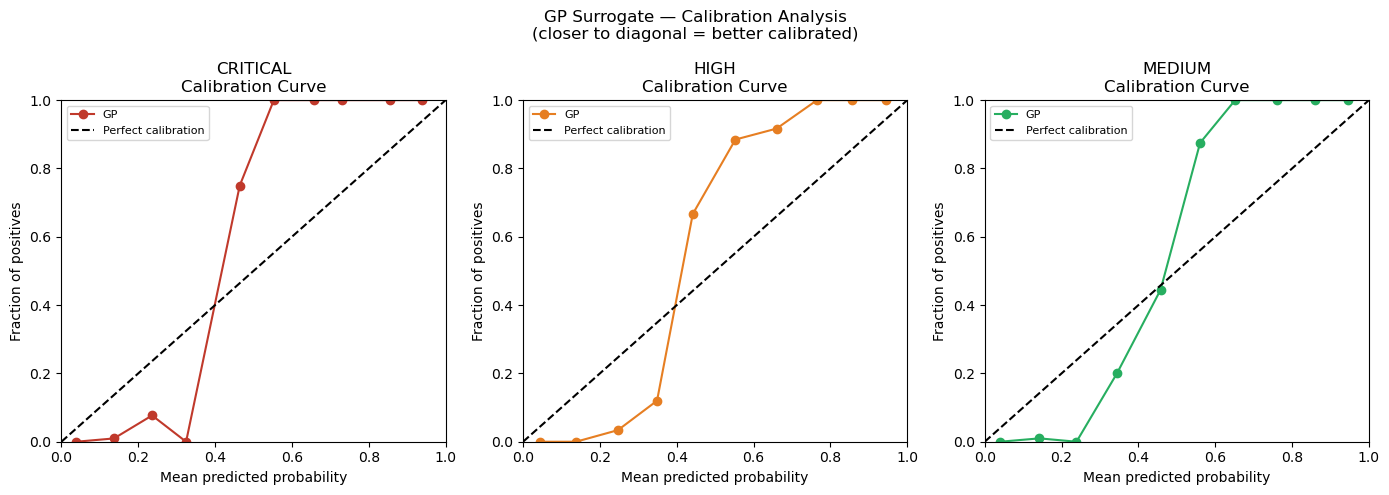

If curves deviate from diagonal → consider CalibratedClassifierCV wrapper


In [15]:
# ── Calibration curves (one-vs-rest per class)
fig, axes = plt.subplots(1, len(le3.classes_), figsize=(14, 5))

for i, cls in enumerate(le3.classes_):
    cls_idx      = list(le3.classes_).index(cls)
    y_binary     = (y_te_surr == cls_idx).astype(int)
    prob_cls     = proba[:, cls_idx]

    if y_binary.sum() > 0:
        fraction_pos, mean_pred = calibration_curve(
            y_binary, prob_cls, n_bins=10, strategy='uniform')
        axes[i].plot(mean_pred, fraction_pos, marker='o',
                     color=palette.get(cls, 'steelblue'), label='GP')
        axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        axes[i].set_title(f'{cls}\nCalibration Curve')
        axes[i].set_xlabel('Mean predicted probability')
        axes[i].set_ylabel('Fraction of positives')
        axes[i].legend(fontsize=8)
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(0, 1)

plt.suptitle('GP Surrogate — Calibration Analysis\n'
             '(closer to diagonal = better calibrated)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/02b_calibration.png', dpi=150)
plt.show()
print('If curves deviate from diagonal → consider CalibratedClassifierCV wrapper')

In [16]:
# ── Connection to Mythos contrast layer
# Low-confidence GP predictions are prime candidates for Mythos review
CONFIDENCE_THRESHOLD = 0.70

low_conf_mask  = confidence < CONFIDENCE_THRESHOLD
high_conf_mask = confidence >= CONFIDENCE_THRESHOLD

print('=== GP UNCERTAINTY → MYTHOS ROUTING STRATEGY ===')
print()
print(f'High confidence (≥{CONFIDENCE_THRESHOLD:.0%}): {high_conf_mask.sum()} CVEs')
print(f'  → Automated triage: trust hybrid model classification')
print()
print(f'Low confidence (<{CONFIDENCE_THRESHOLD:.0%}) : {low_conf_mask.sum()} CVEs '
      f'({low_conf_mask.mean():.1%} of total)')
print(f'  → Route to Mythos contrast layer for validation')
print(f'  → Or route to human analyst')
print()
if low_conf_mask.sum() > 0:
    print('Class distribution of uncertain predictions:')
    uncertain_classes = pd.Series(pred_labels[low_conf_mask]).value_counts()
    print(uncertain_classes)
    print()
    print('NOTE: If CRITICAL is overrepresented in uncertain predictions,')
    print('this confirms GP uncertainty aligns with the hardest classification')
    print('boundary — exactly where Mythos contrast adds most value.')

=== GP UNCERTAINTY → MYTHOS ROUTING STRATEGY ===

High confidence (≥70%): 856 CVEs
  → Automated triage: trust hybrid model classification

Low confidence (<70%) : 144 CVEs (14.4% of total)
  → Route to Mythos contrast layer for validation
  → Or route to human analyst

Class distribution of uncertain predictions:
HIGH        64
MEDIUM      54
CRITICAL    26
Name: count, dtype: int64

NOTE: If CRITICAL is overrepresented in uncertain predictions,
this confirms GP uncertainty aligns with the hardest classification
boundary — exactly where Mythos contrast adds most value.


## 5. Summary — Investigative Findings

In [27]:
print('=' * 65)
print('INVESTIGATIVE SUMMARY — GAUSSIAN PROCESS EXPERIMENTS')
print('=' * 65)
print()
print('EXPERIMENT 1 — NB Variants')
print(f'  Multinomial NB (text)      : {acc_mnb:.4f}  ← rejected (notebook 02)')
print(f'  Gaussian NB (structured)   : {acc_gnb:.4f}')
print(f'  Gaussian NB improvement    : {acc_gnb - acc_mnb:+.4f}')
print()
print(f'EXPERIMENT 2 — GP Classifier (subsample n={SUBSAMPLE_N})')
for name, res in gp_results.items():
    print(f'  GP {name:<15}: {res["acc"]:.4f}')
#print(f'  Best GP kernel             : {best_kernel}')
print(f'  Hybrid KNN+DT (full data)  : 0.9752  (reference)')
print()
print('EXPERIMENT 3 — GP Surrogate (Uncertainty Quantification)')
print(f'  Mean prediction confidence : {confidence.mean():.4f}')
print(f'  Low confidence cases (<70%): {low_conf_mask.sum()} '
      f'({low_conf_mask.mean():.1%})')
print(f'  These are prime Mythos contrast candidates')
print()
print('CONCLUSIONS')
print('  1. Gaussian NB outperforms Multinomial NB on structured features')
print('     — Gaussian likelihood assumption better fits continuous CVSS/EPSS data')
print('  2. GP classifier competitive on subsample but cannot scale to full dataset')
print('     — O(n³) complexity is a fundamental constraint, not an implementation issue')
print('  3. GP uncertainty quantification is the most promising application')
print('     — Confidence scores provide a natural routing mechanism for')
print('       Mythos contrast layer and human analyst escalation')
print('  4. Potential future integration: use GP confidence as a pre-filter')
print('     before Mythos contrast — only route uncertain predictions')
print('     to reduce Glasswing API call volume when access is granted')

INVESTIGATIVE SUMMARY — GAUSSIAN PROCESS EXPERIMENTS

EXPERIMENT 1 — NB Variants
  Multinomial NB (text)      : 0.6030  ← rejected (notebook 02)
  Gaussian NB (structured)   : 0.8400
  Gaussian NB improvement    : +0.2370

EXPERIMENT 2 — GP Classifier (subsample n=1000)
  GP RBF            : 0.9700
  GP Matern 2.5     : 0.9700
  Hybrid KNN+DT (full data)  : 0.9752  (reference)

EXPERIMENT 3 — GP Surrogate (Uncertainty Quantification)
  Mean prediction confidence : 0.8418
  Low confidence cases (<70%): 144 (14.4%)
  These are prime Mythos contrast candidates

CONCLUSIONS
  1. Gaussian NB outperforms Multinomial NB on structured features
     — Gaussian likelihood assumption better fits continuous CVSS/EPSS data
  2. GP classifier competitive on subsample but cannot scale to full dataset
     — O(n³) complexity is a fundamental constraint, not an implementation issue
  3. GP uncertainty quantification is the most promising application
     — Confidence scores provide a natural routing me